In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
# load the dataset
df =  pd.read_csv(r"C:\Users\chris\ML prediction\heart_disease_cleaned.csv")
df.head()

,age,sex,chest_pain,resting_bp,serum_chol,fasting_blood_sugar,resting_electrocardiog,max_heart_rate,exang,oldpeak,slope,no_vessel,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     920 non-null    int64  
 1   sex                     920 non-null    object 
 2   chest_pain              920 non-null    object 
 3   resting_bp              920 non-null    float64
 4   serum_chol              920 non-null    float64
 5   fasting_blood_sugar     920 non-null    bool   
 6   resting_electrocardiog  920 non-null    object 
 7   max_heart_rate          920 non-null    float64
 8   exang                   920 non-null    bool   
 9   oldpeak                 920 non-null    float64
 10  slope                   920 non-null    object 
 11  no_vessel               920 non-null    float64
 12  thal                    920 non-null    object 
 13  num                     920 non-null    int64  
dtypes: bool(2), float64(5), int64(2), object(5

In [4]:
# Statistical summary
df.describe()

,age,resting_bp,serum_chol,max_heart_rate,oldpeak,no_vessel,num
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,131.995652,199.908696,137.692391,0.853261,0.227174,0.995652
std,9.424685,18.451300,109.040171,25.145235,1.058049,0.628936,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,177.750000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,0.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [5]:
# check missing values
missing = df.isna().sum().sort_values(ascending=False)
print(missing)

age                       0
sex                       0
chest_pain                0
resting_bp                0
serum_chol                0
fasting_blood_sugar       0
resting_electrocardiog    0
max_heart_rate            0
exang                     0
oldpeak                   0
slope                     0
no_vessel                 0
thal                      0
num                       0
dtype: int64


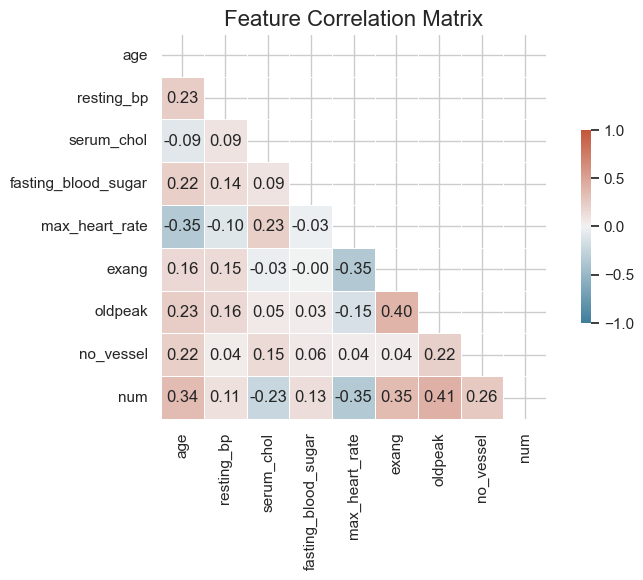

In [6]:
import seaborn as sns
# numerical_col = df.select_dtypes(includes = 'number')
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(9, 5))
cmap = sns.diverging_palette(230, 20, as_cmap=True) # customize a diverging color
sns.heatmap(
    corr, 
    mask=mask, 
    cmap=cmap,
    vmin= -1,
    vmax=1, 
    center=0,
    annot=True,          # Adds the numerical correlation values
    fmt=".2f",           # Formats annotations to 2 decimal places
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .5}
)

plt.title('Feature Correlation Matrix', fontsize=16)
plt.show()

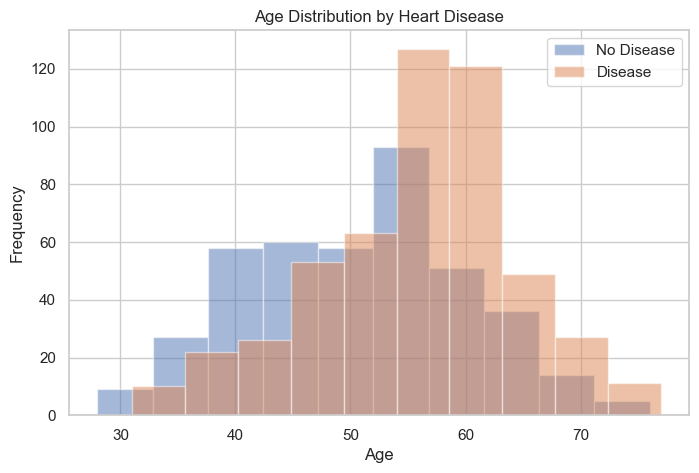

In [7]:
import matplotlib.pyplot as plt
df_plot = df.copy()
df_plot["num"] = df_plot["num"].apply(lambda x: 0 if x == 0 else 1)

no_disease = df_plot[df_plot["num"] == 0]
disease = df_plot[df_plot["num"] == 1]

plt.figure()

plt.hist(no_disease["age"], alpha=0.5, label="No Disease")
plt.hist(disease["age"], alpha=0.5, label="Disease")

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution by Heart Disease")
plt.legend()

plt.show()

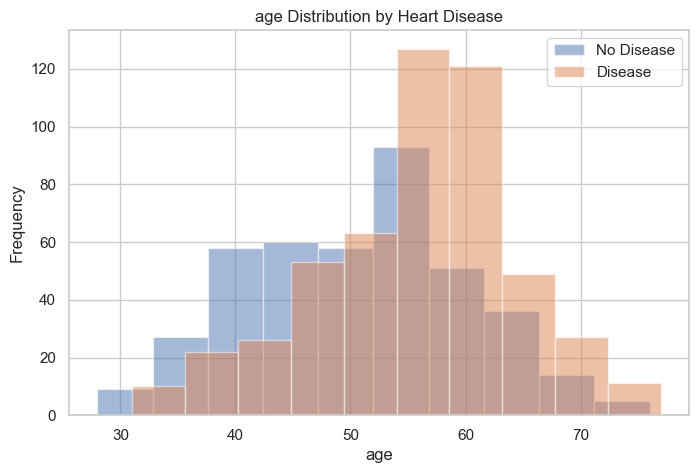

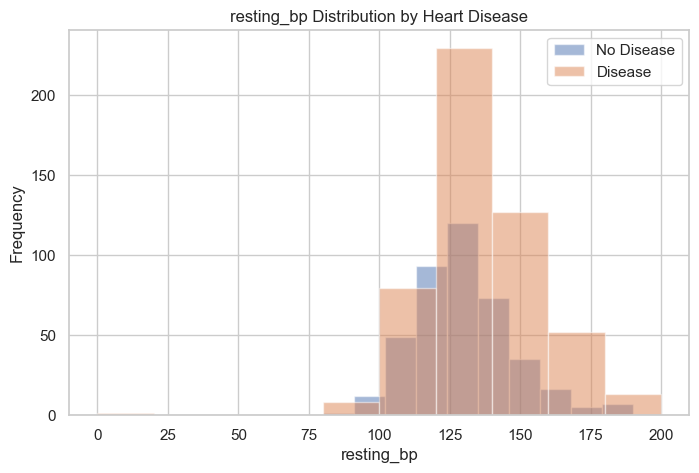

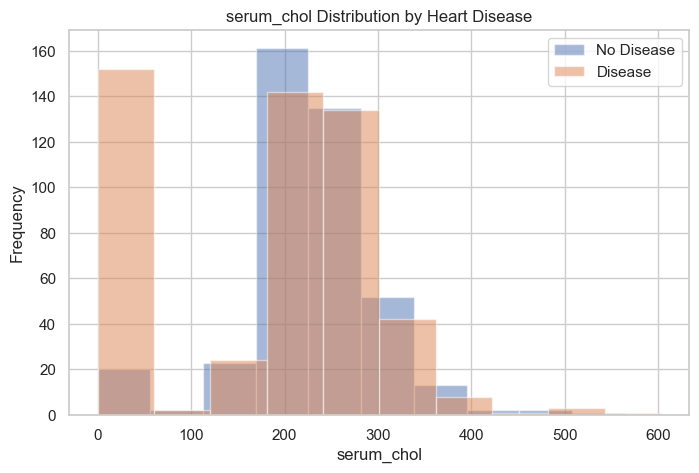

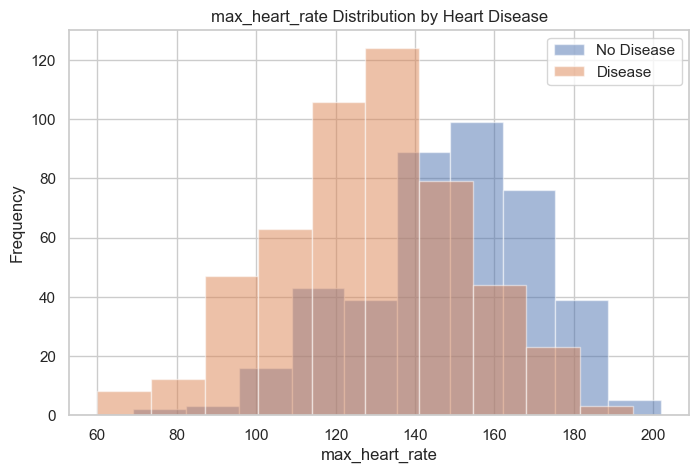

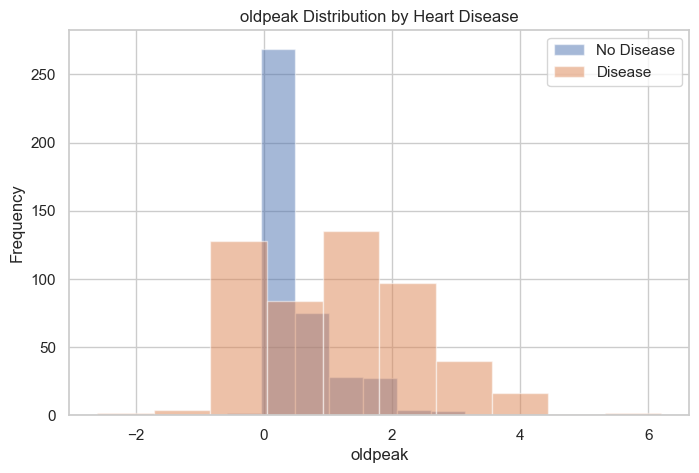

In [8]:
features_to_plot = ["age", "resting_bp", "serum_chol", "max_heart_rate", "oldpeak"]
for col in features_to_plot:
    plt.figure()
    plt.hist(no_disease[col], alpha=0.5, label="No Disease")
    plt.hist(disease[col], alpha=0.5, label="Disease")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"{col} Distribution by Heart Disease")
    plt.legend()
    plt.show()

<Figure size 800x500 with 0 Axes>

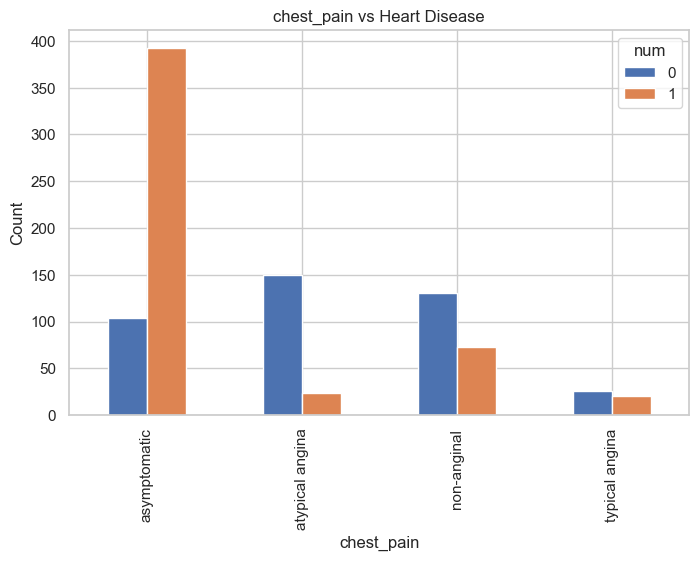

<Figure size 800x500 with 0 Axes>

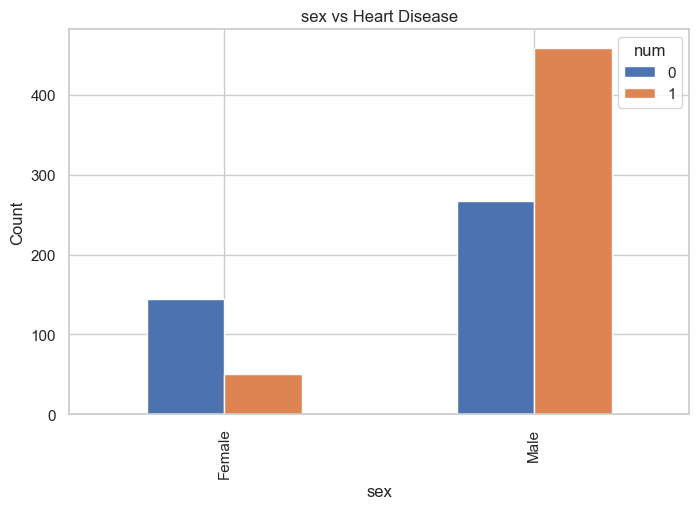

<Figure size 800x500 with 0 Axes>

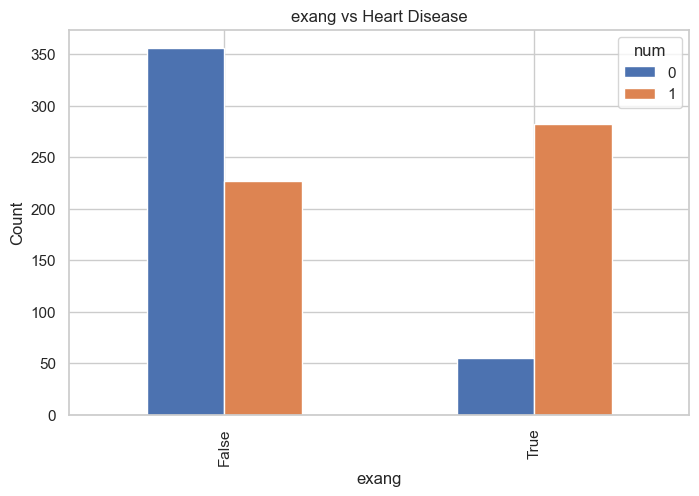

<Figure size 800x500 with 0 Axes>

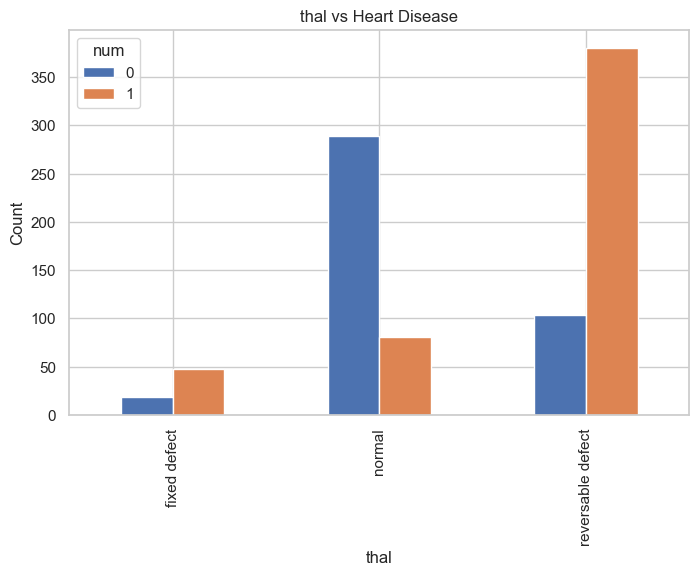

<Figure size 800x500 with 0 Axes>

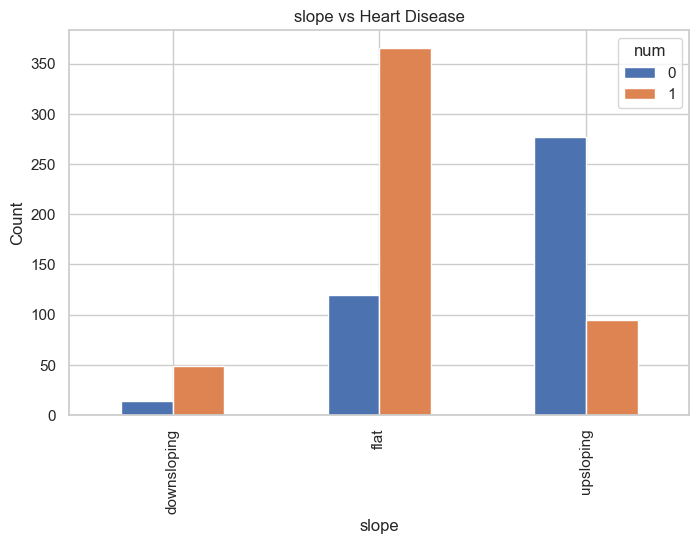

In [9]:
cat_features = ["chest_pain", "sex", "exang", "thal", "slope"]
for col in cat_features:
    plt.figure()
    pd.crosstab(df_plot[col], df_plot["num"]).plot(kind="bar")
    
    plt.title(f"{col} vs Heart Disease")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.show()

In [10]:
selected_features = [
    "sex",                # gender of patient
    "age",                # age in years
    "serum_chol",         # cholesterol level
    "max_heart_rate",     # maximum heart rate achieved
    "oldpeak",            # ST depression (stress indicator)
    "resting_bp",         # resting blood pressure
    "chest_pain",         # chest pain type
    "thal",               # thalassemia result
    "slope",              # slope of ECG
    "no_vessel",          # number of major vessels
    "exang"               # exercise induced angina
]

df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)
# Define target column (what we are predicting)
target = "num"  # change if your dataset uses another name

# Create feature matrix (X) and target vector (y)
X = df[selected_features]  # input variables
y = df[target]             # output variable


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Define categorical features (text / categories)
cat_features = [
    "sex",          # Male / Female
    "chest_pain",   # types of chest pain
    "thal",         # defect type
    "slope",        # ECG slope
    "exang"         # True / False
]

# Define numerical features (continuous values)
num_features = [
    "age",
    "serum_chol",
    "max_heart_rate",
    "oldpeak",
    "resting_bp",
    "no_vessel"
]

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

numeric_pipeline = Pipeline([("scaler", StandardScaler())])
categorical_pipeline = Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([("num", numeric_pipeline, num_features),("cat", categorical_pipeline, cat_features)])

results = []
for name, model in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append((name, acc, auc))

In [13]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC_AUC"])
results_df = results_df.sort_values(by="ROC_AUC", ascending=False)

print(results_df)

                 Model  Accuracy   ROC_AUC
2    Gradient Boosting  0.858696  0.922324
4                  KNN  0.880435  0.919083
1        Random Forest  0.880435  0.919083
3                  SVM  0.885870  0.914373
0  Logistic Regression  0.869565  0.911437


In [14]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc")
    print(f"{name}: Mean AUC = {scores.mean():.4f}")

Logistic Regression: Mean AUC = 0.8825
Random Forest: Mean AUC = 0.8953
Gradient Boosting: Mean AUC = 0.8545
SVM: Mean AUC = 0.8832
KNN: Mean AUC = 0.8552


<Figure size 800x500 with 0 Axes>

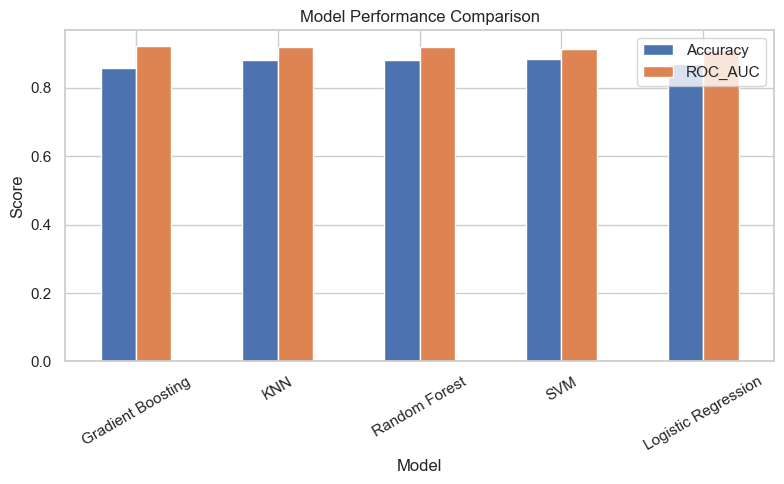

In [15]:
# Visualization of model comparison results (bar chart + ROC curves)
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve, auc

# --- BAR CHART: Accuracy and ROC-AUC ---
plt.figure()
results_df.set_index("Model")[["Accuracy", "ROC_AUC"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

📊 Bar Chart Insight

“Gradient Boosting achieved the highest ROC-AUC and accuracy, indicating superior predictive performance. Random Forest followed closely, demonstrating strong generalization.”

In [16]:
from sklearn.metrics import roc_curve, auc

roc_data = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    roc_data[name] = (fpr, tpr, roc_auc)

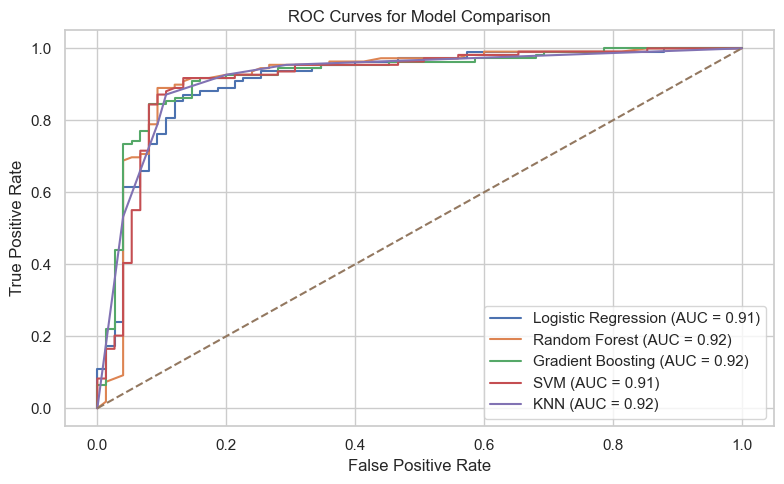

In [17]:
import matplotlib.pyplot as plt

plt.figure()

for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Model Comparison")

plt.legend()
plt.tight_layout()
plt.show()

📈 ROC Curve Insight

“The ROC curve for Gradient Boosting dominates others, indicating better discrimination between patients with and without heart disease. Models closer to the diagonal (e.g., KNN) show weaker predictive capability.”

In [18]:
best_model = max(roc_data.items(), key=lambda x: x[1][2])
print("Best Model:", best_model[0], "AUC:", best_model[1][2])

Best Model: Gradient Boosting AUC: 0.9223241590214067


In [19]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'serum_chol',
                                                   'max_heart_rate', 'oldpeak',
                                                   'resting_bp', 'no_vessel']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'chest_pain', 'thal',
                                                   'slope', 'exang'])])),
                ('model',
                 XGBClassifier(base_score=N...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [20]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Final ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        75
           1       0.91      0.88      0.90       109

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184

Final ROC-AUC: 0.9207339449541284


In [21]:
import shap

# Extract trained model
model = final_pipeline.named_steps["model"]
# Transform data
X_transformed = final_pipeline.named_steps["preprocessing"].transform(X_train)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_transformed)

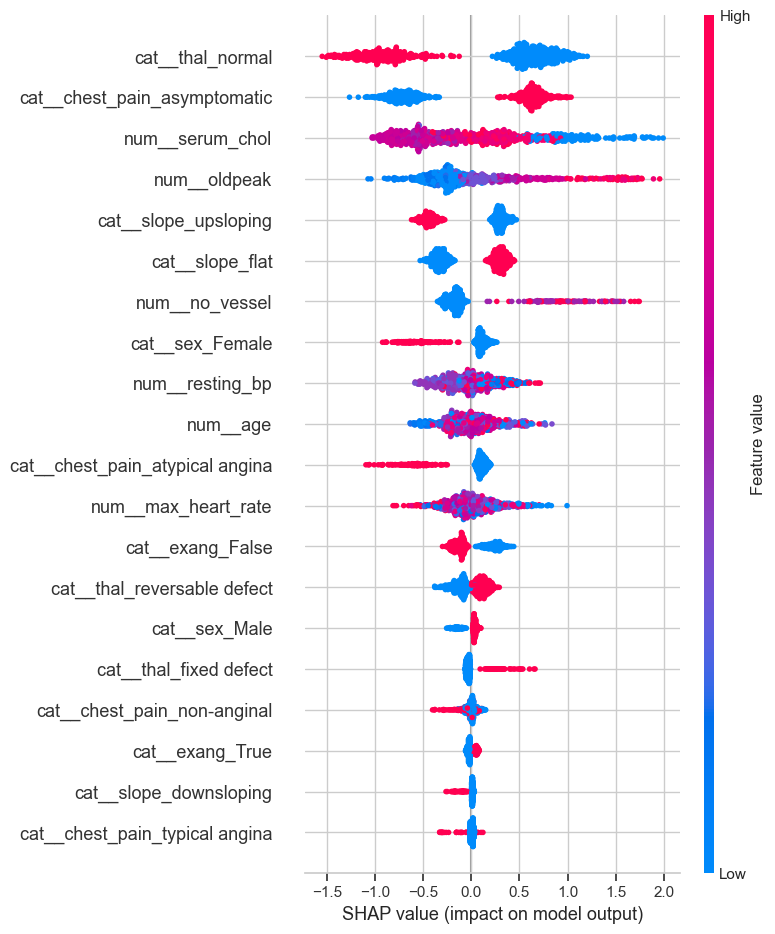

In [22]:
feature_names = final_pipeline.named_steps["preprocessing"].get_feature_names_out()
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

In [23]:
import pickle
pickle.dump(final_pipeline, open("xgboost_heart_model.pkl", "wb"))
# with open("xgboost_heart_model.pkl", "wb") as f:
#     pickle.dump(final_pipeline, f)

In [24]:
import joblib
joblib.dump(final_pipeline, "xgboost_heart_model.joblib")
print("✅ Model saved with joblib")

✅ Model saved with joblib


In [25]:
with open("xgboost_heart_model.joblib", "rb") as f:
    pipeline = joblib.load(f)

print("✅ Model loaded successfully.")

✅ Model loaded successfully.


In [26]:
import pandas as pd

sample_patient = pd.DataFrame([{
    "age": 54,
    "sex": "male",
    "chest_pain": "asymptomatic",
    "resting_bp": 130,
    "serum_chol": 250,
    "fasting_bs": 0,
    "rest_ecg": "lv hypertrophy",
    "max_heart_rate": 150,
    "exang": 0,
    "oldpeak": 1.2,
    "slope": "downsloping",
    "no_vessel": 0,
    "thal": "fixed defect"
}])

In [27]:
preds = pipeline.predict(sample_patient)
probs = pipeline.predict_proba(sample_patient)[:, 1]

print("Prediction:", "Heart Disease" if preds == 1 else "No Heart Disease")
print("Probability:", np.round(probs * 100, 2), "%")

Prediction: Heart Disease
Probability: [67.63] %


**📌 Prediction Summary**

*Risk Score: ~67.6%*

*Classification: Moderate–High Risk ⚠️*

In [28]:
import shap


# Extract trained model
model = pipeline.named_steps["model"]

# Transform training data (needed for SHAP background)
X_train_transformed = pipeline.named_steps["preprocessing"].transform(X_train)

# Create explainer
explainer = shap.TreeExplainer(model)

# Transform sample input
sample_transformed = pipeline.named_steps["preprocessing"].transform(sample_patient)
shap_values = explainer.shap_values(sample_transformed)
feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()

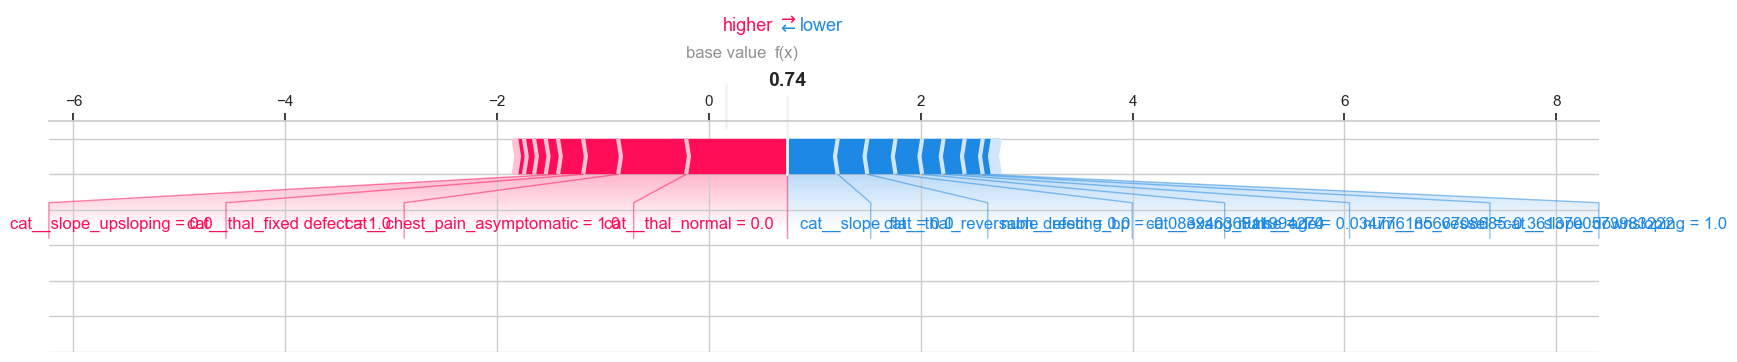

In [29]:
shap.force_plot(
    explainer.expected_value,
    shap_values,
    sample_transformed,
    feature_names=feature_names,
    matplotlib=True
)

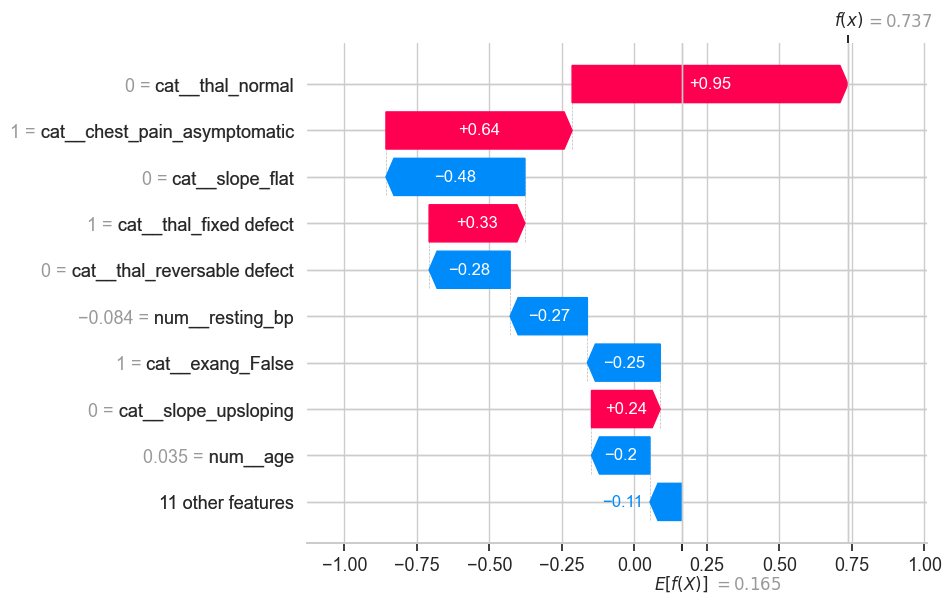

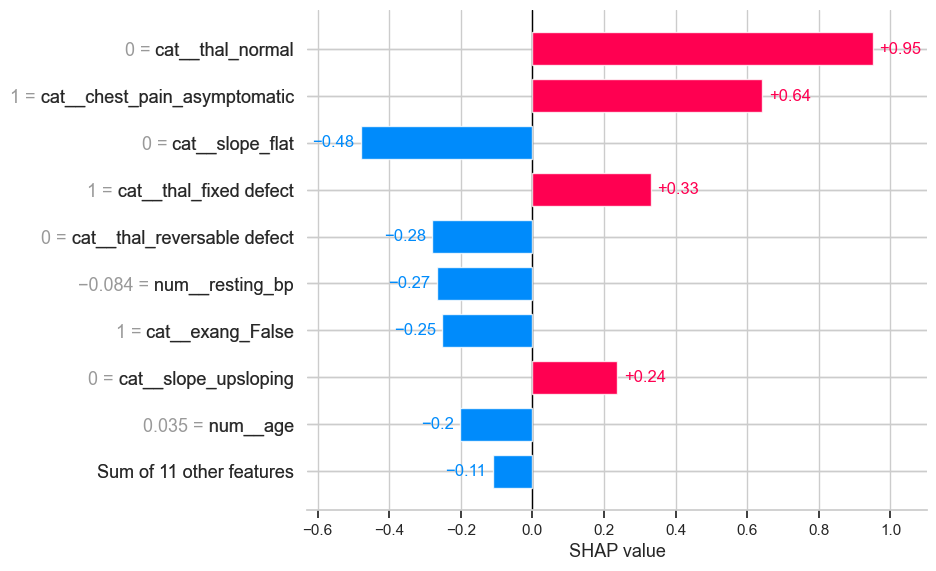

In [30]:
import shap
import matplotlib.pyplot as plt

# Create proper SHAP explanation object
exp = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=sample_transformed[0],
    feature_names=feature_names
)

# Plot
shap.plots.waterfall(exp, max_display=10)

plt.show()

shap.plots.bar(exp)

**🔴 Features Increasing Risk (Positive SHAP Values)**

These pushed the model toward Heart Disease:

* Asymptomatic chest pain

    → Strong clinical indicator; often linked to silent ischemia
* Fixed defect (thalassemia)

    → Suggests prior myocardial damage or perfusion issues
* Downsloping ST segment (slope)

    → Associated with abnormal ECG response during stress
* Elevated cholesterol (250 mg/dL)

    → Major cardiovascular risk factor

**🔵 Features Reducing Risk (Negative SHAP Values)**

These pushed the model toward No Disease:

* No exercise-induced angina (exang = 0)

    → Suggests better cardiac response to stress
* Relatively good max heart rate (150 bpm)

    → Indicates functional cardiac capacity
* Moderate age (54)

    → Risk present but not extreme

##### 🧠 FINAL INTERPRETATION
The model predicted a moderate-to-high risk of heart disease `(67.6%)`. This prediction is primarily driven by `asymptomatic chest pain, fixed defect thalassemia, and a downsloping ST segment`, all of which are clinically associated with underlying cardiac abnormalities. However, the absence of exercise-induced angina and a relatively high maximum heart rate partially mitigate the risk. The model effectively balances these competing factors to produce the final prediction.”

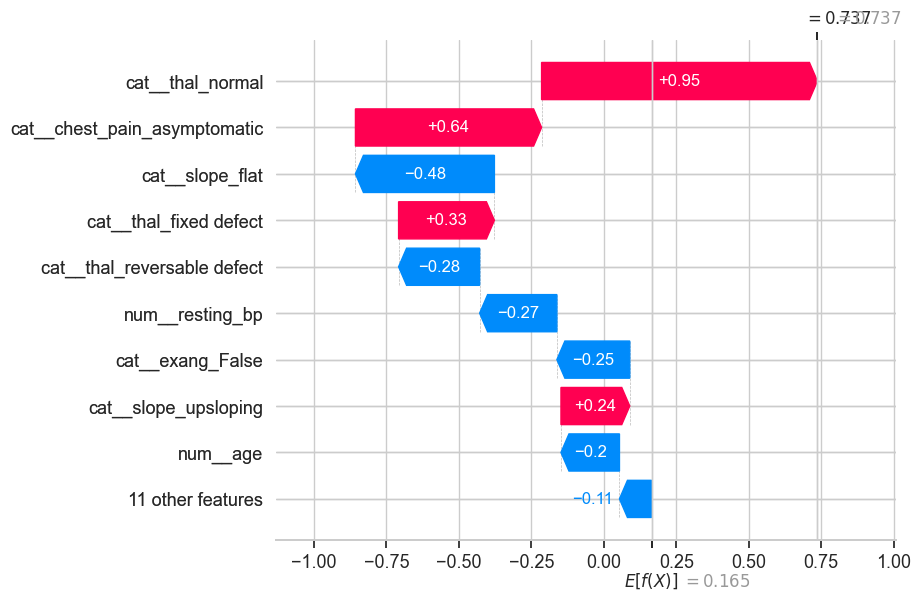

In [31]:
# Waterfall plot shows feature contribution clearly
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    feature_names=feature_names
)


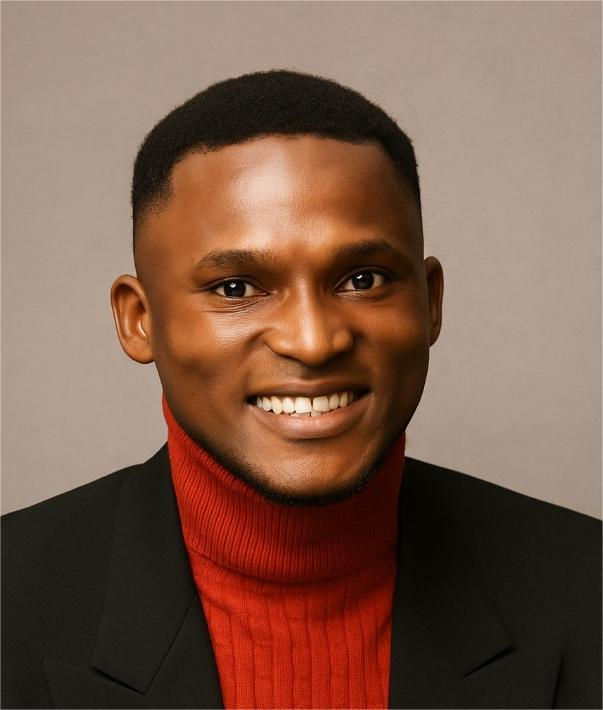

In [32]:
# Use this code in a Python Code Cell in your Jupyter Notebook.
# It uses the IPython.display module to force the rendering of HTML content.
from IPython.display import HTML
import base64
import os

# --- Step 1: Define the path to your local image ---
# IMPORTANT: Ensure this path is correct and accessible by your Python environment.
IMAGE_PATH = r"C:\Users\chris\OneDrive\Documents\Desktop\WhatsApp Image 2025-09-19 at 15.13.37_501d24f0.jpg"

def image_to_base64(filepath):
    """Reads a local image file and converts it to a Base64 encoded string."""
    if not os.path.exists(filepath):
        print(f"Error: File not found at path: {filepath}")
        return "https://placehold.co/100x100/7E3D8E/ffffff?text=Image+Error" # Fallback
    
    try:
        with open(filepath, "rb") as image_file:
            # Get the image file extension to determine the MIME type
            _, ext = os.path.splitext(filepath)
            mime_type = f"image/{ext.lower().lstrip('.')}"
            
            # Encode the image data
            encoded_string = base64.b64encode(image_file.read()).decode('utf-8')
            
            # Return the full data URI
            return f"data:{mime_type};base64,{encoded_string}"
    except Exception as e:
        print(f"Error processing image file: {e}")
        return "https://placehold.co/100x100/FF5733/ffffff?text=Processing+Error" # Fallback

# --- Step 2: Generate the Base64 Data URI ---
IMAGE_DATA_URI = image_to_base64(IMAGE_PATH)

html_content = f"""
<!-- 
    This HTML and CSS snippet is designed to be rendered within a 
    Jupyter Notebook using IPython.display.HTML.
-->
<div style="text-align: center;"> <!-- Added outer div for centering -->
    <div class="profile-card-container">
        <style>
            /* Embed the CSS directly for Jupyter Notebook rendering */
            .profile-card-container {{
                display: flex;
                align-items: center;
                /* Centering the block element itself */
                margin: 0 auto; 
                padding: 30px; /* Increased padding */
                border: 1px solid #dcdcdc; /* Lighter border */
                border-radius: 16px; /* More rounded corners */
                box-shadow: 0 6px 12px rgba(0, 0, 0, 0.1); /* Stronger shadow for visibility */
                /* Max-width adjusted for wider appearance */
                max-width: 100%; 
                width: 700px; 
                font-family: 'Inter', sans-serif;
                background-color: #ffffff; /* White background for contrast */
                transition: transform 0.2s, box-shadow 0.2s;
            }}

            .profile-card-container:hover {{
                transform: translateY(-3px); /* Subtle lift effect */
                box-shadow: 0 10px 20px rgba(0, 0, 0, 0.15); 
            }}

            .profile-image-wrapper {{
                /* UPDATED: Increased size for better visibility */
                width: 140px; 
                height: 200px;
                border-radius: 50%; /* Maintains circular shape */
                overflow: hidden; 
                border: 5px solid #7E3D8E; /* Thicker, noticeable border */
                flex-shrink: 0; 
                box-shadow: 0 0 10px rgba(0, 0, 0, 0.2); /* Shadow around image */
            }}

            .profile-image-wrapper img {{
                width: 100%;
                height: 100%;
                object-fit: cover; 
            }}

            .profile-info {{
                margin-left: 30px; /* Increased margin */
                color: #2c3e50; /* Darker text for readability */
                flex-grow: 1; 
                text-align: left; 
            }}

            .profile-info h3 {{
                margin: 0 0 5px 0;
                font-size: 1.8em; /* Larger name */
                color: #34495e; 
                font-weight: 600;
            }}

            .profile-info p {{
                margin: 6px 0;
                font-size: 1.1em; /* Larger contact details */
                color: #555;
            }}
        </style>

        <div class="profile-image-wrapper">
            <!-- The image source is now the Base64 encoded string -->
            <img src="{IMAGE_DATA_URI}" alt="Profile Picture">
       
            </div>
            <div class="profile-info">
            <h3>Odunayomide YAKUBU</h3>
            <p>Data Scientist | ML Enthusiast | Data Storyteller </p>
            <p>Email✉️: christianamide6@email.com</p>
            <p>LinkedIn : Odunayomide Yakubu</p>
            <p>Github: Odunayomide Yakubu</p>
            <p>Contact 📞: +234 9132 112 946 </p>
        </div>
    </div>
</div>
"""

# Render the HTML content
HTML(html_content)


In [33]:
print(X_train.columns.tolist())

['sex', 'age', 'serum_chol', 'max_heart_rate', 'oldpeak', 'resting_bp', 'chest_pain', 'thal', 'slope', 'no_vessel', 'exang']


In [34]:
import sklearn
print(f"Jupyter sklearn version: {sklearn.__version__}")

Jupyter sklearn version: 1.6.1
